In [1]:
import numpy as np 
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import glob
import seaborn as sns
# sns.set_style("darkgrid")
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from num2words import num2words
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import os
from distfit import distfit
import sys
import scipy
import rasterio
from scipy.interpolate import CubicSpline
from scipy.integrate import quad
from scipy.stats import multivariate_normal
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
%matplotlib inline
# %matplotlib notebook

## 5K Country total Tx

In [2]:
Russia_total= 15508
China_total= 9333
Argentina_total =7092
Brazil_total=9201
Spain_total=6340
France_total=9406

## Read Country DB parameters

In [3]:
csv_files = ['./database/USA.csv']
#France has 9393 Tx

# --Create an empty dataframe to store the combined data-- #
df = pd.DataFrame()

# Loop through each CSV file and append its contents to the combined dataframe
for csv_file in (csv_files):
    df_temp = pd.read_csv(csv_file)
    df = pd.concat([df, df_temp],ignore_index=True) 
# read Tx params into numpy arrays
df=df.dropna()
power=df['EIRP'].to_numpy()
lat_128=df['Latitude in degrees'].to_numpy()
lon_128=df['Longitude in degrees'].to_numpy()
# convert Tx coords into HEALPix pixels
pix=hp.ang2pix(128,lon_128,lat_128,lonlat=True)

In [4]:
# make number of Tx per pixel map
Tx_num_128=np.zeros(hp.nside2npix(128))
for pi in pix:
    Tx_num_128[pi]+=1
hp.mollview(Tx_num_128,flip='geo',cmap='plasma',norm='hist',title='')
plt.show()

In [5]:
# making total Tx power in each pixel
Tx_pow_128=np.zeros(hp.nside2npix(128))
for index,p in enumerate(pix):
    Tx_pow_128[p]+=(power[index])
hp.mollview(Tx_pow_128,flip='geo',cmap='viridis',norm='hist',min=300)
plt.show()

# Fitting PDF to Tx params

In [6]:
# read Tx params of selected 5k country
fr_df=pd.read_csv('./database/USA.csv')
fr_df=fr_df.dropna()
lat=fr_df['Latitude in degrees'].to_numpy()
lon=fr_df['Longitude in degrees'].to_numpy()
power=fr_df['EIRP'].to_numpy()
freq=fr_df['Frequency(MHz)'].to_numpy()

In [7]:
# Define number of synthetic datapoints to generate
# finval=Russia_total-len(lat)
finval=26165

In [8]:
# Bin width using Freedman Diaconis rule
def FDrule(data):
    # Calculate interquartile range
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    
    # Calculate Freedman-Diaconis bin width
    n = len(data)
    bin_width = 2 * iqr / (n ** (1/3))

    # Calculate number of bins
    data_range = max(data) - min(data)
    num_bins = int(data_range / bin_width) + 1
    
    return num_bins

## Country HEALPix map as mask

In [9]:
# France shapefile was downloaded from https://gadm.org/download_country.html and rasterized using QGIS
# Open the GeoTIFF file
file_path = '/home/pratush/Desktop/USA_shpraster.tif'
src = rasterio.open(file_path)

# Read the raster data as a numpy array
data = src.read(1)  # Assuming a single-band raster

# Find pixels with non-zero values
non_zero_pixels = np.where(data != 0)

# Get the coordinates of non zero pixels
templat=[]
templon=[]
for y, x in zip(*non_zero_pixels):
    lonval, latval = src.xy(y, x)  # Get the longitude and latitude of the pixel
    templat.append(latval)
    templon.append(lonval)


In [10]:
# Making a mask for generated data
temppix=hp.ang2pix(128,templon,templat,lonlat=True)
template=np.zeros(hp.nside2npix(128))
for pi in temppix:
    template[pi]+=1
template=np.where(template != 0, 1, 0)
hp.mollview(template,flip='geo')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/Country_shp.pdf',dpi=600)

## FMSCAN template

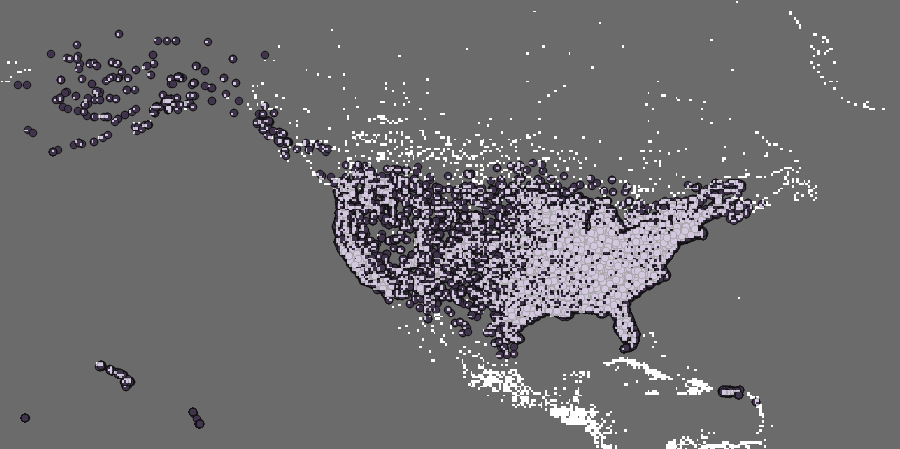

In [41]:

##Read the tif file##
FM = tiff.imread('/home/pratush/hires_fmscan.tif')
FM_array = np.array(FM)
FM_array[FM_array<4]=0
# Define the spherical coordinates#
theta2 = np.linspace(np.radians(0), np.radians(180), num=FM_array.shape[0],endpoint=False)
phi2 = np.linspace(-np.radians(180), np.radians(180), num=FM_array.shape[1],endpoint=False)

# Set angular resolution#
nside = 128

## Make empty healpix mask and pixel values vector##
FMSCAN_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts2 = np.zeros(hp.nside2npix(nside), dtype=int)
for i in range(len(theta2)):
    for j in range(len(phi2)):
        pixel2 = hp.ang2pix(nside, theta2[i], phi2[j])
        FMSCAN_map[pixel2] += FM_array[i, j]
        pixel_counts2[pixel2] += 1

# Average value of each pixel#
FMSCAN_map[pixel_counts2>0] /= pixel_counts2[pixel_counts2>0 ]



In [42]:
FMSCAN_map=np.where(FMSCAN_map != 0, 1, 0)

In [43]:
hp.mollview(FMSCAN_map,flip='geo',norm='hist',title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/FMscan_Filter.pdf',dpi=600)

## Final template combining shp and FMSCAN

In [14]:
fintemp_pix=np.where(FMSCAN_map&template!=0)
fin_temp=np.zeros(hp.nside2npix(128))
for i in fintemp_pix:
        fin_temp[i]+=1
hp.mollview(fin_temp,flip='geo')
ruslon,ruslat=hp.pix2ang(128,fintemp_pix,lonlat=True)
ruslon[ruslon>180]-=360
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/Final_filter.pdf',dpi=600)

In [15]:
def shapecheck(lon,lat,name):
    checkpix=hp.ang2pix(128,lon,lat,lonlat=True)
    checkmap=np.zeros(hp.nside2npix(128))
    for pi in checkpix:
        checkmap[pi]+=1
    checkmap=np.where(checkmap != 0, 1, 0)
    return hp.mollview(checkmap,flip='geo',title=name,cmap='inferno')
    


### Modelling Latitude

In [16]:
binw=FDrule(lat)
# Fit a probability density function
distlat = distfit(distr='full',bins=binw)
distlat.fit_transform(lat)

# Plot the fitted distribution
distlat.plot()
plt.title('Fitted Probability Density Function')
plt.show()

# Get information about the best-fitted distribution
print("Best fitted distribution:", distlat.model['name'])
print("Parameters:", distlat.model['params'])


### Model longitude

In [17]:
binwi=FDrule(lon)
# Fit a probability density function
distlon = distfit(distr='full',bins=binwi)
distlon.fit_transform(lon)

# Plot the fitted distribution
distlon.plot()
plt.title('Fitted Probability Density Function')
plt.show()

# Get information about the best-fitted distribution
print("Best fitted distribution:", distlon.model['name'])
print("Parameters:", distlon.model['params'])


### Model Tx power

In [18]:
powbin=FDrule(power)
# Fit a probability density function
distpow = distfit(distr='powerlaw',bins=powbin)
distpow.fit_transform(power)

# Plot the fitted distribution
distpow.plot()
plt.title('Fitted Probability Density Function')
plt.show()

# Get information about the best-fitted distribution
print("Best fitted distribution:", distpow.model['name'])
print("Parameters:", distpow.model['params'])


In [19]:
check_synth=distpow.generate(finval)

np.size(np.where(check_synth<0))

### Model Tx Freq

In [20]:
freqbin=FDrule(freq)
# Fit a probability density function
distfreq = distfit(distr='full',bins=freqbin)
distfreq.fit_transform(freq)

# Plot the fitted distribution
distfreq.plot()
plt.title('Fitted Probability Density Function')
plt.show()

# Get information about the best-fitted distribution
print("Best fitted distribution:", distfreq.model['name'])
print("Parameters:", distfreq.model['params'])


### Distfit Gen

In [21]:
validpix = np.nonzero(template)[0] 

nayalat = distlat.generate(30000)
nayalon = distlon.generate(30000)

# Filter values within the desired ranges
newlat = [value for value in nayalat if -90 <= value <= 90]
newlon = [value for value in nayalon if -180 <= value <= 180]

# Trim the longer list to match the length of the shorter one
min_length = min(len(newlat), len(newlon))
newlat = newlat[:min_length]
newlon = newlon[:min_length]

newpix = hp.ang2pix(128, newlon, newlat, lonlat=True)
finpix = []
for pixie in newpix:
    if pixie in validpix:  
        finpix.append(pixie)
    if len(finpix)==finval:
        break

In [22]:
finlon,finlat=hp.pix2ang(128,finpix,lonlat=True)
print(len(finlat))
print(finval)


## Spline trial

## Spline fit power

In [23]:
data = power
# Create a histogram
hist2, bin_edges2 = np.histogram(data,bins='fd')
# Calculate midpoints of bins
bin_midpoints2 = (bin_edges2[1:] + bin_edges2[:-1]) / 2
# Fit a cubic spline to the histogram
cs2 = CubicSpline(bin_midpoints2, hist2)
# Generate x values for the spline plot
x_vals2 = np.linspace(bin_midpoints2.min(), bin_midpoints2.max(), finval)
# Plot the histogram and the cubic spline
plt.hist(data, bins=FDrule(data), label='Histogram')
plt.plot(x_vals2, cs2(x_vals2), 'r-', label='Cubic Spline')

plt.title('Histogram with Cubic Spline Fit')
plt.legend()
plt.yscale('log')
plt.show()


In [24]:
x_values2 = np.linspace(np.min(power),np.max(power),finval) 
corrval2=np.min(cs2(x_values2))
def curve2(x):
    curr=cs2(x)
    return curr-corrval2
# Calculate the area under the curve
area_under_curve2, _ = quad(curve2,np.min(power) , np.max(power))

# Create the unnormalized PDF function
def pdf_unnormalized(x):
    return curve2(x) / area_under_curve2

# Normalize the PDF manually to ensure the sum equals 1
pdf_values2 = pdf_unnormalized(x_values2)
pdf_normalized2 = pdf_values2 / np.sum(pdf_values2)

# Plot the original curve
plt.plot(x_values2, curve2(x_values2), label='Original Curve')
plt.show()
# Plot the normalized probability density function (PDF)
plt.plot(x_values2, pdf_normalized2, label='Normalized PDF')
plt.title('Normalized Probability Density Function (PDF)')
plt.show()

### fit spline pdf to longitude

In [25]:
data = lon
(max(lon)-min(lon))/0.458
# Create a histogram
hist, bin_edges = np.histogram(data,bins='fd')
# Calculate midpoints of bins
bin_midpoints = (bin_edges[1:] + bin_edges[:-1]) / 2
# Fit a cubic spline to the histogram
cs = CubicSpline(bin_midpoints, hist)
# Generate x values for the spline plot
x_vals = np.linspace(bin_midpoints.min(), bin_midpoints.max(), finval)
# Plot the histogram and the cubic spline
plt.hist(data, bins=FDrule(data), label='Histogram')
plt.plot(x_vals, cs(x_vals), 'r-', label='Cubic Spline')

plt.title('Histogram with Cubic Spline Fit')
plt.legend()
plt.show()


In [26]:
x_values = np.linspace(np.min(lon),np.max(lon),finval) 
corrval=np.min(cs(x_values))
def curve(x):
    curr=cs(x)
    return curr-corrval
# Calculate the area under the curve
area_under_curve, _ = quad(curve,np.min(lon) , np.max(lon))

# Create the unnormalized PDF function
def pdf_unnormalized(x):
    return curve(x) / area_under_curve

# Normalize the PDF manually to ensure the sum equals 1
pdf_values = pdf_unnormalized(x_values)
pdf_normalized = pdf_values / np.sum(pdf_values)

# Plot the original curve
plt.plot(x_values, curve(x_values), label='Original Curve')
plt.show()
# Plot the normalized probability density function (PDF)
plt.plot(x_values, pdf_normalized, label='Normalized PDF')
plt.title('Normalized Probability Density Function (PDF)')
plt.show()

### fit spline pdf to latitude

In [27]:
data = lat

# Create a histogram
hist1, bin_edges1 = np.histogram(data, bins='fd')

# Calculate midpoints of bins
bin_midpoints1 = (bin_edges1[1:] + bin_edges1[:-1]) / 2

# Fit a cubic spline to the histogram
cs1 = CubicSpline(bin_midpoints1, hist1)

# Generate x values for the spline plot
x_vals1 = np.linspace(bin_midpoints1.min(), bin_midpoints1.max(), finval)

# Plot the histogram and the cubic spline
plt.hist(data, bins=FDrule(lat), label='Histogram')
plt.plot(x_vals1, cs1(x_vals1), 'r-', label='Cubic Spline')

plt.title('Histogram with Cubic Spline Fit')
plt.legend()
plt.show()


In [28]:
x_values1 = np.linspace(np.min(lat),np.max(lat),finval) 
corrval1=np.min(cs1(x_values1))
def curve1(x):
    curr=cs1(x)
    return curr-corrval1


# Calculate the area under the curve
area_under_curve1, _ = quad(curve1,np.min(lat) , np.max(lat))

# Create the unnormalized PDF function
def pdf_unnormalized1(x):
    return curve1(x) / area_under_curve1

# Normalize the PDF manually to ensure the sum equals 1
pdf_values1 = pdf_unnormalized1(x_values1)
pdf_normalized1 = pdf_values1 / np.sum(pdf_values1)
# Plot the original curve
plt.plot(x_values1, curve1(x_values1), label='Original Curve')
plt.show()
# Plot the normalized probability density function (PDF)
plt.plot(x_values1, pdf_normalized1, label='Normalized PDF')
plt.title('Normalized Probability Density Function (PDF)')
plt.show()

### Spline Gen

In [29]:
spline_pow=np.random.choice(x_values2,size=finval,p=pdf_normalized2)

In [30]:
pdf_normalized2.shape

In [31]:
plt.hist(power,bins=FDrule(power))
plt.show()

In [32]:
# filter the generated data

verynew_lat = np.random.choice(x_values1,size=30000,p=pdf_normalized1)
verynew_lon = np.random.choice(x_values,size=30000,p=pdf_normalized)

# Filter values within the desired ranges
newlats = [value for value in verynew_lat if -90 <= value <= 90]
newlons = [value for value in verynew_lon if -180 <= value <= 180]

# Trim the longer list to match the length of the shorter one
min_length = min(len(newlats), len(newlons))
newlats = newlats[:min_length]
newlons = newlons[:min_length]

newpixs = hp.ang2pix(128, newlons, newlats, lonlat=True)
finpix1 = []
for pixie in newpixs:
    if pixie in validpix:  
        finpix1.append(pixie)
    if len(finpix1)==finval:
        break

In [33]:
spline_lon,spline_lat=hp.pix2ang(128,finpix1,lonlat=True)
saverdf=pd.DataFrame({'Longitude':spline_lon,'Latitude':spline_lat})
# saverdf.to_csv('/home/pratush/Downloads/USA_Splinepoints.csv')

## CDF trial

In [34]:
data = lon 

# Creating histogram to estimate the CDF
hist, bins = np.histogram(data, bins=FDrule(lon), density=True)
cumulative = np.cumsum(hist * np.diff(bins))  # Estimating cumulative distribution function (CDF)

# Generating synthetic data based on the CDF
# synthetic_data = np.interp(np.random.uniform(0, 1, finval), cumulative, bins[:-1])

# Plotting original data and synthetic data
plt.figure(figsize=(8, 5))
plt.hist(data, bins=20, alpha=0.5, label='Original Data')
# plt.hist(synthetic_data, bins=20, alpha=0.5, label='Synthetic Data')
plt.legend()
plt.show()


In [35]:
data = lat

# Creating histogram to estimate the CDF
hist1, bins1 = np.histogram(data, bins=FDrule(lat), density=True)
cumulative1 = np.cumsum(hist1 * np.diff(bins1))  # Estimating cumulative distribution function (CDF)






In [36]:
FDrule(lat)

### CDF Gen

In [37]:
 np.all(np.diff(bins[:-1]) > 0)

In [38]:
very_new_lat = np.interp(np.random.uniform(0, 1, 30000), np.flip(cumulative1), bins1[:-1])
very_new_lon = np.interp(np.random.uniform(0, 1, 30000), np.flip(cumulative), bins[:-1])


# Filter values within the desired ranges
new_lats = [value for value in very_new_lat if -90 <= value <= 90]
new_lons = [value for value in very_new_lon if -180 <= value <= 180]

# Trim the longer list to match the length of the shorter one
min_length = min(len(new_lats), len(new_lons))
new_lats = new_lats[:min_length]
new_lons = new_lons[:min_length]

newpixss = hp.ang2pix(128, new_lons, new_lats, lonlat=True)
finpix2 = []
for pixie in newpixss:
    if pixie in validpix:  
        finpix2.append(pixie)
    if len(finpix2)==finval:
        break

In [39]:
cdf_lon,cdf_lat=hp.pix2ang(128,finpix2,lonlat=True)

In [ ]:
np.unique(new_lats)

In [ ]:
cdf_lon[cdf_lon>180]-=360

In [ ]:
saverdf={'Lon':cdf_lon,'Lat':cdf_lat}
dfcheck=pd.DataFrame(saverdf)
dfcheck.to_csv('/home/pratush/Desktop/univarUSA.csv')

In [ ]:
dfdata={'Lon':cdf_lon,'Lat':cdf_lat}
usa_model=pd.DataFrame(data)
# usa_model.to_csv('/home/pratush/Desktop/rus_gen.csv')

## Final checks

In [ ]:
# distfit generated map:
shapecheck(finlon,finlat,"Distfit w/ filter")

In [ ]:
shapecheck((spline_lon),(spline_lat),'Spline w/ filter')
shapecheck(lon,lat,'original')
plt.show()


In [ ]:
#cdf generated map:
shapecheck(cdf_lon,cdf_lat,'CDF w/ filter')

## Unfiltered synth data checks

In [ ]:
shapecheck(verynew_lon,verynew_lat,'Spline')
shapecheck(very_new_lon,very_new_lat,'CDF')
# shapecheck(nayalon,nayalat,'Distfit')



## Make synthetic database

In [ ]:
synth_lon=cdf_lon
synth_lat=cdf_lat
# brute force for frequency?
synth_freq=distfreq.generate(finval)
synth_power=distpow.generate(finval)

In [ ]:
# save synth DB into starfire DB
# synth_data={'Latitude in degrees':synth_lat,'Longitude in degrees':synth_lon,'Frequency(MHz)':synth_freq,'EIRP':synth_power}
# synth_df=pd.DataFrame(synth_data)
# synth_df.to_csv('./database/Russia_synth.csv')

# Country wise parameter trends

In [ ]:
# Have to make country wise median power as x axis and country pop dens as y axis
# outline of algorithm for this:
# open each csv file and and make median of power, ang2pix of any Tx and corresponding pix of popdens map(country wise)
# then plot them both

In [ ]:
# ##---------Read the tif file---------##
# HDI=tiff.imread('/home/pratush/Desktop/pop_raster_world.tif')
# HDI_array=np.array(HDI)

# #----------Define the spherical coordinates----------#
# theta1 = np.linspace(np.radians(0), np.radians(180), num=HDI_array.shape[0],endpoint=False)
# phi1 = np.linspace(-np.radians(180), np.radians(180), num=HDI_array.shape[1],endpoint=False)

# #---------- Set angular resolution----------#
# nside = 128

# ##--------Make empty healpix mask and pixel values vector--------##
# HDI_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
# pixel_counts1 = np.zeros(hp.nside2npix(nside), dtype=int)


# for i in range(len(theta1)):
#     for j in range(len(phi1)):
#         pixel1 = hp.ang2pix(nside, theta1[i], phi1[j])
#         HDI_map[pixel1] += HDI_array[i, j]
#         pixel_counts1[pixel1] += 1

# #--------Average value of each pixel--------#
# HDI_map[pixel_counts1>0] /= pixel_counts1[pixel_counts1>0 ]


In [ ]:
# csv_files = glob.glob('./database/*.csv')
# #France has 9393 Tx
# med_vals=[]
# y_params=[]
# # --Create an empty dataframe to store the combined data-- #
# df = pd.DataFrame()

# for csv_file in (csv_files):
#     df_temp = pd.read_csv(csv_file)
#     df_temp=df_temp.dropna(subset=['Latitude in degrees', 'Longitude in degrees','EIRP'])
#     temp_pow=df_temp['EIRP'].to_numpy()
#     med_vals.append(np.median(temp_pow))
#     temp_lat=df_temp['Latitude in degrees'].to_numpy()
#     temp_lon=df_temp['Longitude in degrees'].to_numpy()
#     sellat,sellon=np.median(temp_lat),np.median(temp_lon)
#     tempix=hp.ang2pix(128,sellon,sellat,lonlat=True)
#     print(sellat,sellon)
#     y_params.append(HDI_map[tempix])
# # read Tx params into numpy arrays


In [ ]:
# csv_file

In [ ]:
# plt.scatter(med_vals,y_params)
# plt.xscale('log')
# plt.yscale('log')

In [ ]:
# plt.hist(med_vals,bins=FDrule(med_vals))
# # plt.xlim(500,900)
# plt.show()

## Fit power law using scipy optimize

In [ ]:
histpow, binspow = np.histogram(power, bins=600)


In [ ]:
plt.scatter(histpow,binspow[:-1],marker='1',linewidths=0.7)
# plt.xscale('log')
# plt.yscale('log')
plt.show()

In [ ]:
# plt.scatter(histpow,binspow[:-1],marker='1',linewidths=0.7)
# plt.xscale('log')
# plt.yscale('log')
axaf = np.linspace(0,1000000,1000000)
plt.scatter(axaf,1-np.exp(-axaf))
# plt.xscale('log')
# plt.yscale('log')
plt.show()

In [ ]:
def power_law(x, a, b):
    return a*(x**b)

x_data = binspow[:-1]
y_data = histpow

popt, pcov = curve_fit(power_law, x_data, (y_data))

a_fit, b_fit = popt

# Plotting
plt.scatter(x_data, y_data)
plt.plot(x_data, power_law(x_data, a_fit, b_fit), 'r-')

# plt.xscale('log'),plt.yscale('log')
plt.show()

print(f"Optimized parameters: a = {a_fit}, b = {b_fit}")


In [ ]:
np.log10(y_data)

In [ ]:
y_data=np.log10(y_data)
y_data[np.abs(y_data)==np.inf]=0
# valdex=np.where
plt.xscale('log')

In [ ]:
plt.scatter((x_data),(y_data))
plt.xscale('log')
plt.show()

In [ ]:
np.size((power))

In [ ]:
1-1
